### **Proyecto: Predicción del Precio de Bitcoin mediante Series Temporales**

### **Importar librerías**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")


### **Descarga de datos históricos de Bitcoin**

In [37]:
# Definimos el símbolo (ticker) de Bitcoin en Yahoo Finance
ticker = "BTC-USD"

# Definimos el rango de fechas que queremos descargar
start_date = "2015-01-01"          # Desde inicios de 2015 (Bitcoin ya tenía varios años)
end_date = "2025-02-20"            # Hasta una fecha cercana a hoy (Se puede poner None para la fecha actual)

# Descargamos los datos
print(f"Descargando datos de {ticker} desde {start_date} hasta {end_date}")

Descargando datos de BTC-USD desde 2015-01-01 hasta 2025-02-20


In [38]:
df = yf.download(
    tickers = ticker,              # El símbolo que queremos
    start = start_date,            # Fecha de inicio
    end = end_date,                # Fecha de fin (opcional, si no se pone → hasta hoy)
    interval = "1d",               # Intervalo: 1 día (diario) → ideal para empezar
    auto_adjust = True,            # Ajusta automáticamente precios por splits/dividendos (útil aunque en crypto casi no aplica)
    progress = True              # Muestra una barra de progreso (puedes poner False si molesta)
)

# Si todo salió bien, mostramos información básica
print("\nDescarga completada.")
print(f"Forma del DataFrame:{df.shape[0]} filas, {df.shape[1]} columnas")
print("\nPrimeras 5 filas del dataset:")
display(df.head())                 # display() es mejor que print() en Jupyter/Colab

print("\nÚltimas 5 filas (datos más recientes):")
display(df.tail())

[*********************100%***********************]  1 of 1 completed



Descarga completada.
Forma del DataFrame:3703 filas, 5 columnas

Primeras 5 filas del dataset:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800



Últimas 5 filas (datos más recientes):


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2025-02-15,97580.351562,97975.039062,97240.195312,97508.382812,17047266288
2025-02-16,96175.031250,97725.593750,96060.976562,97580.492188,16536755396
2025-02-17,95773.382812,97032.234375,95243.546875,96179.007812,27336550690
2025-02-18,95539.546875,96695.375000,93388.835938,95773.812500,37325720482
2025-02-19,96635.609375,96855.593750,95011.968750,95532.531250,28990872862


In [ ]:
# Revision de la tipo de datos de cada columna y datos faltantes
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3703 entries, 2015-01-01 to 2025-02-19
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   3703 non-null   float64
 1   (High, BTC-USD)    3703 non-null   float64
 2   (Low, BTC-USD)     3703 non-null   float64
 3   (Open, BTC-USD)    3703 non-null   float64
 4   (Volume, BTC-USD)  3703 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 173.6 KB


In [ ]:
# Revision de las caracteristicas estadisticas de las columnas → medidas de tendencia central
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,3703.000000,3703.000000,3703.000000,3703.000000,3.703000e+03
mean,21207.593283,21654.781384,20691.005147,21182.897033,1.953101e+10
std,23853.656356,24334.841619,23300.680480,23825.737097,2.074962e+10
min,178.102997,211.731003,171.509995,176.897003,7.860650e+06
25%,2708.039917,2774.635010,2632.105103,2699.185059,1.300945e+09
50%,9842.666016,10074.238281,9600.728516,9823.429688,1.584821e+10
75%,34375.361328,35224.371094,33374.716797,34307.302734,3.060972e+10
max,106146.265625,109114.882812,105291.734375,106147.296875,3.509679e+11


In [ ]:
# Comprobamos que no haya datos faltantes
df.isna().sum()

Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

### **Limpieza rápida: Simplificar nombres de columnas**

In [42]:
# Como yfinance devuelve MultiIndex, quitamos el indice que no nos interesa → BTC-USD 
df.columns = df.columns.get_level_values(0)

print("Columnas después de limpiar:")
print(df.columns.tolist())

Columnas después de limpiar:
['Close', 'High', 'Low', 'Open', 'Volume']


In [43]:
# Vista rápida de nuevo
display(df.head(3))
display(df.tail(3))

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-02-17,95773.382812,97032.234375,95243.546875,96179.007812,27336550690
2025-02-18,95539.546875,96695.375000,93388.835938,95773.812500,37325720482
2025-02-19,96635.609375,96855.593750,95011.968750,95532.531250,28990872862


### **Verificación: Duplicados y continuidad de fechas**

In [44]:
# Duplicados completos (filas idénticas en TODAS las columnas)
duplicados_completos = df.duplicated().sum()
print(f"Filas duplicadas completas (idénticas en todas las columnas): {duplicados_completos}")

# Duplicados por fecha (mismo índice de fecha)
duplicados_por_fecha = df.index.duplicated().sum()
print(f"Fechas duplicadas en el índice: {duplicados_por_fecha}")

if duplicados_por_fecha > 0:
    print("Fechas duplicadas encontradas. Mostrando las primeras:")
    display(df[df.index.duplicated(keep=False)].head(6))
else:
    print("→ No hay fechas duplicadas.")

Filas duplicadas completas (idénticas en todas las columnas): 0
Fechas duplicadas en el índice: 0
→ No hay fechas duplicadas.


In [45]:
# Verificar continuidad de fechas (diferencias de 1 día)
# Creamos una serie con la diferencia en días entre fechas consecutivas
diff_fechas = df.index.to_series().diff().dt.days

# Quitamos el primer NaT (porque no hay anterior)
diff_fechas = diff_fechas.dropna()

# ¿Cuántas diferencias NO son exactamente 1 día?
huecos = (diff_fechas != 1).sum()
print(f"\nNúmero de saltos/huecos (diferencia ≠ 1 día): {huecos}")

if huecos > 0:
    print("Fechas donde hubo salto (diferencia > 1 día):")
    # Mostramos las fechas problemáticas
    problematicas = diff_fechas[diff_fechas != 1]
    for fecha, dias in problematicas.items():
        print(f"  → Entre {fecha - pd.Timedelta(days=dias)} y {fecha}: {dias} días de diferencia")
else:
    print("→ Todas las fechas son consecutivas (diferencia = 1 día). ¡Excelente!")

# Resumen final
print("\nResumen de integridad:")
print(f"• Filas totales: {len(df)}")
print(f"• Fechas únicas: {df.index.nunique()}")
print(f"• Período: desde {df.index.min().date()} hasta {df.index.max().date()}")
print(f"• Días esperados aproximados: {(df.index.max() - df.index.min()).days + 1}")


Número de saltos/huecos (diferencia ≠ 1 día): 0
→ Todas las fechas son consecutivas (diferencia = 1 día). ¡Excelente!

Resumen de integridad:
• Filas totales: 3703
• Fechas únicas: 3703
• Período: desde 2015-01-01 hasta 2025-02-19
• Días esperados aproximados: 3703


### **Primer EDA visual: Evolución del precio de cierre (Close)**

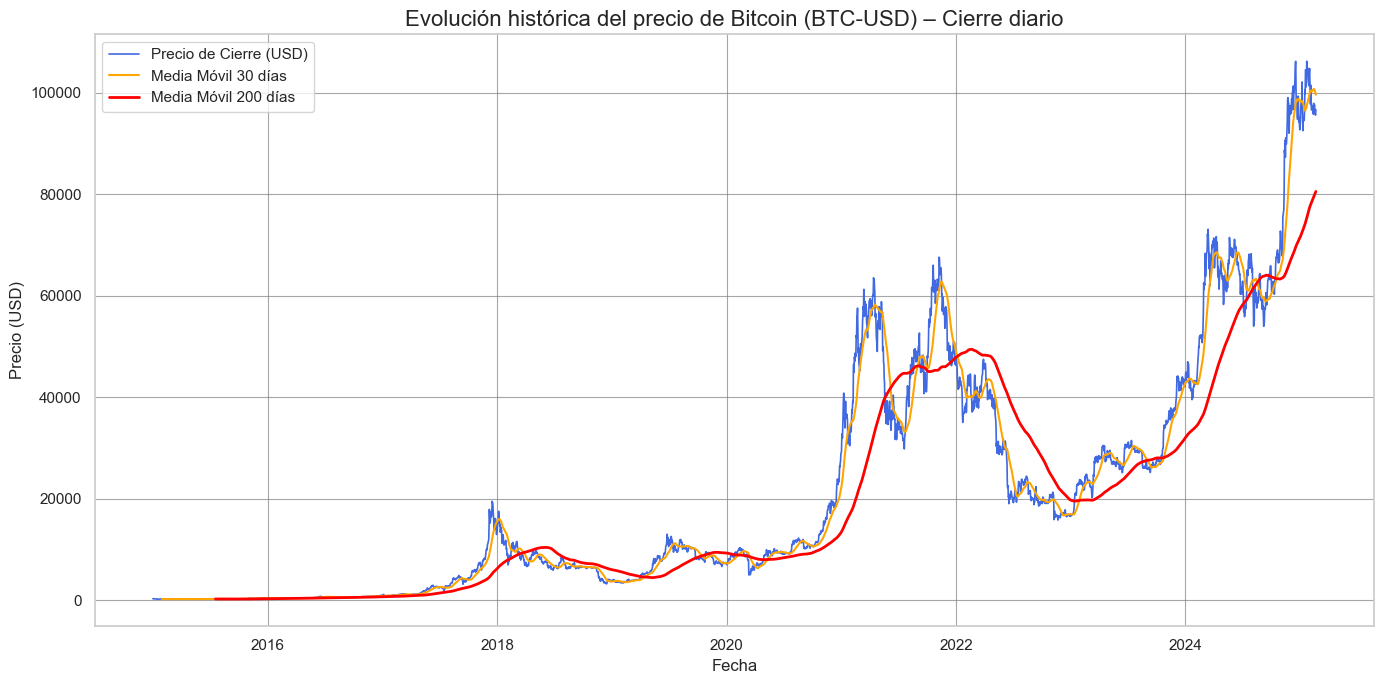

In [ ]:
plt.figure(figsize=(14, 7))

# Graficamos Close
plt.plot(df.index, df['Close'], label='Precio de Cierre (USD)', color='royalblue', linewidth=1.2)

# Añadimos medias móviles simples
df['MA_30'] = df['Close'].rolling(window=30).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.plot(df.index, df['MA_30'], label='Media Móvil 30 días', color='orange', linewidth=1.5)
plt.plot(df.index, df['MA_200'], label='Media Móvil 200 días', color='red', linewidth=2)

plt.title('Evolución histórica del precio de Bitcoin (BTC-USD) – Cierre diario', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio (USD)', fontsize=12)
plt.legend()
plt.grid(True, 
         color='gray',          
         linestyle='-',         
         linewidth=0.8,         
         alpha=0.7)
plt.tight_layout()
plt.show()

### **Retornos diarios**

In [47]:
# Retorno simple diario (porcentaje)
df['Return_simple'] = df['Close'].pct_change() * 100

# Retorno logarítmico diario (más común en modelado financiero)
df['Return_log'] = np.log(df['Close'] / df['Close'].shift(1)) * 100

# Primeras filas para verificar
print("Primeras filas con retornos:")
display(df[['Close', 'Return_simple', 'Return_log']].head(8))

# Estadísticas básicas de los retornos
print("\nEstadísticas de retornos diarios (%):")
display(df[['Return_simple', 'Return_log']].describe().round(4))

# Asimetría y curtosis (útil para entender la distribución)
print("\nAsimetría (skew) y curtosis de retornos log:")
print(df['Return_log'].skew().round(4), "(skew)")
print(df['Return_log'].kurtosis().round(4), "(kurtosis)")

Primeras filas con retornos:


Price,Close,Return_simple,Return_log
Date,,,
2015-01-01,314.248993,NaN,NaN
2015-01-02,315.032013,0.249172,0.248862
2015-01-03,281.082001,-10.776686,-11.402782
2015-01-04,264.195007,-6.007853,-6.195895
2015-01-05,274.473999,3.890684,3.816904
2015-01-06,286.188995,4.268163,4.179588
2015-01-07,294.337006,2.847073,2.807297
2015-01-08,283.348999,-3.733138,-3.804604



Estadísticas de retornos diarios (%):


Price,Return_simple,Return_log
count,3702.0000,3702.0000
mean,0.2206,0.1547
std,3.6110,3.6372
min,-37.1695,-46.4730
25%,-1.2182,-1.2256
50%,0.1320,0.1319
75%,1.6720,1.6582
max,25.2472,22.5119



Asimetría (skew) y curtosis de retornos log:
-0.752 (skew)
11.6585 (kurtosis)


### **Visualización - Distribución de retornos logarítmicos**

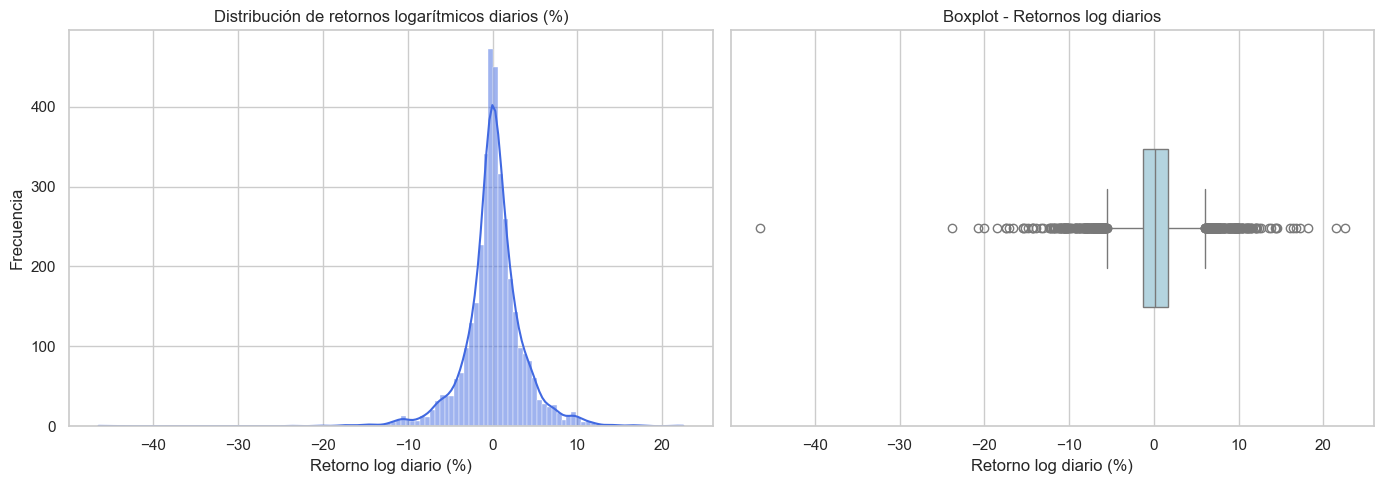

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma + KDE
sns.histplot(df['Return_log'].dropna(), 
             kde=True, 
             ax=axes[0], 
             color='royalblue', 
             bins=120)
axes[0].set_title('Distribución de retornos logarítmicos diarios (%)')
axes[0].set_xlabel('Retorno log diario (%)')
axes[0].set_ylabel('Frecuencia')

# Boxplot (para ver outliers)
sns.boxplot(x=df['Return_log'].dropna(), 
            ax=axes[1], 
            color='lightblue', 
            width=0.4)
axes[1].set_title('Boxplot - Retornos log diarios')
axes[1].set_xlabel('Retorno log diario (%)')

plt.tight_layout()
plt.show()

### **Volatilidad rolling (desviación estándar anualizada aproximada)**

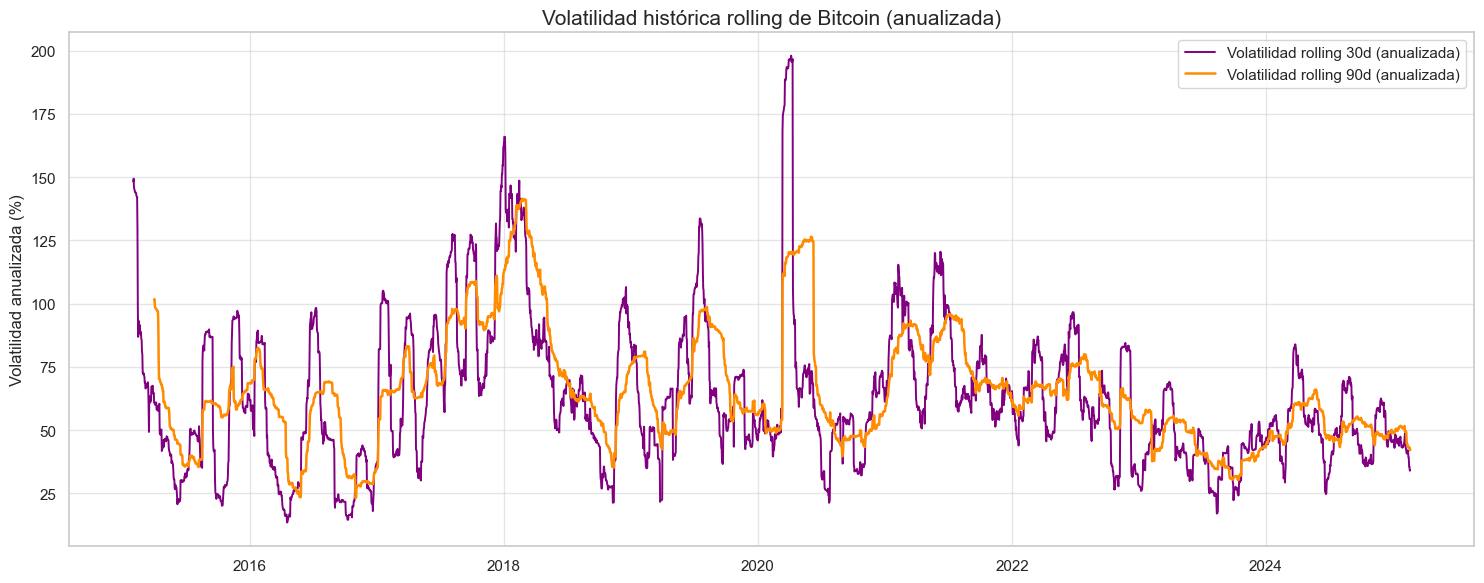

In [49]:
# Volatilidad rolling 
window_30  = 30
window_90  = 90

df['Vol_30d'] = df['Return_log'].rolling(window=window_30).std() * np.sqrt(365)
df['Vol_90d'] = df['Return_log'].rolling(window=window_90).std() * np.sqrt(365)

plt.figure(figsize=(15, 6))

plt.plot(df['Vol_30d'], label=f'Volatilidad rolling {window_30}d (anualizada)', color='purple', lw=1.4)
plt.plot(df['Vol_90d'], label=f'Volatilidad rolling {window_90}d (anualizada)', color='darkorange', lw=1.8)

plt.title('Volatilidad histórica rolling de Bitcoin (anualizada)', fontsize=15)
plt.ylabel('Volatilidad anualizada (%)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### **Volumen + precio**

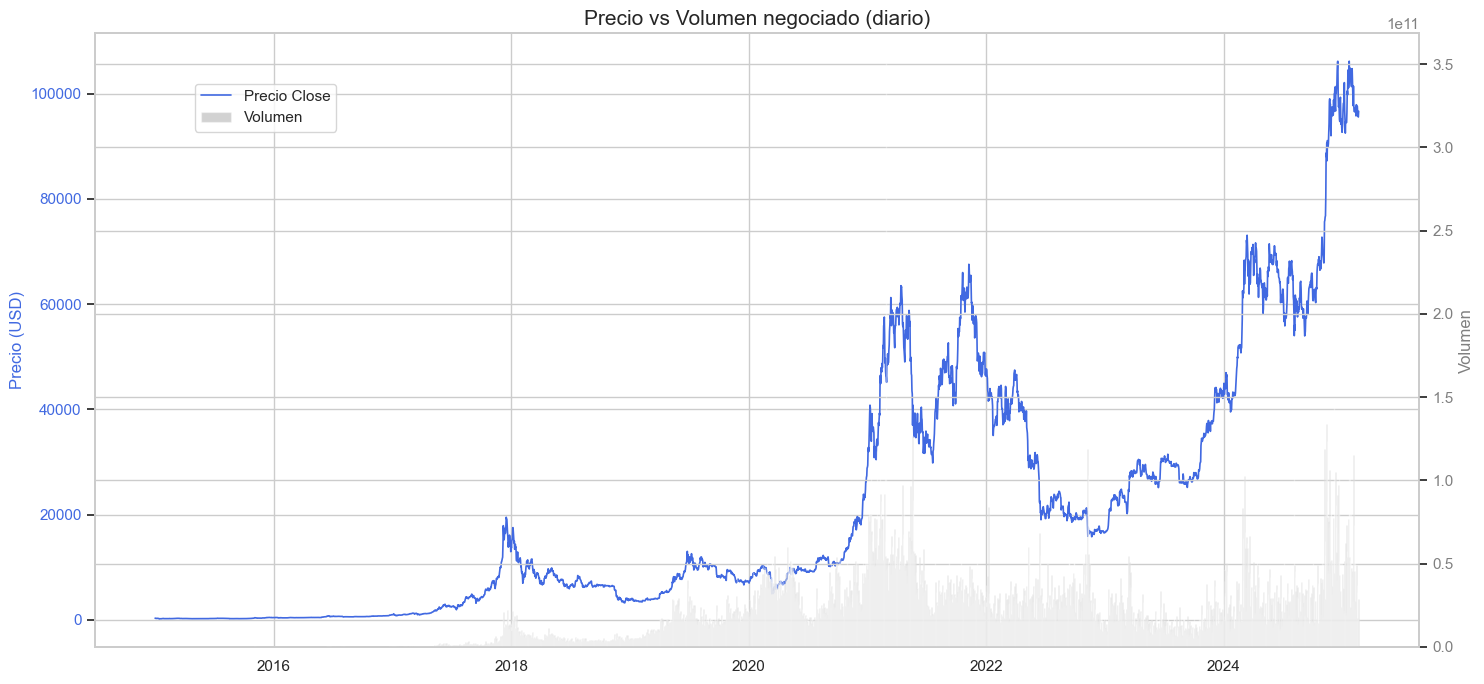

In [50]:
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.plot(df['Close'], color='royalblue', label='Precio Close', lw=1.2)
ax1.set_ylabel('Precio (USD)', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')

ax2 = ax1.twinx()
ax2.bar(df.index, df['Volume'], color='gray', alpha=0.35, width=1.0, label='Volumen')
ax2.set_ylabel('Volumen', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.title('Precio vs Volumen negociado (diario)', fontsize=15)
fig.legend(loc='upper left', bbox_to_anchor=(0.13, 0.88))
plt.tight_layout()
plt.show()

### **Boxplot de retornos por año**

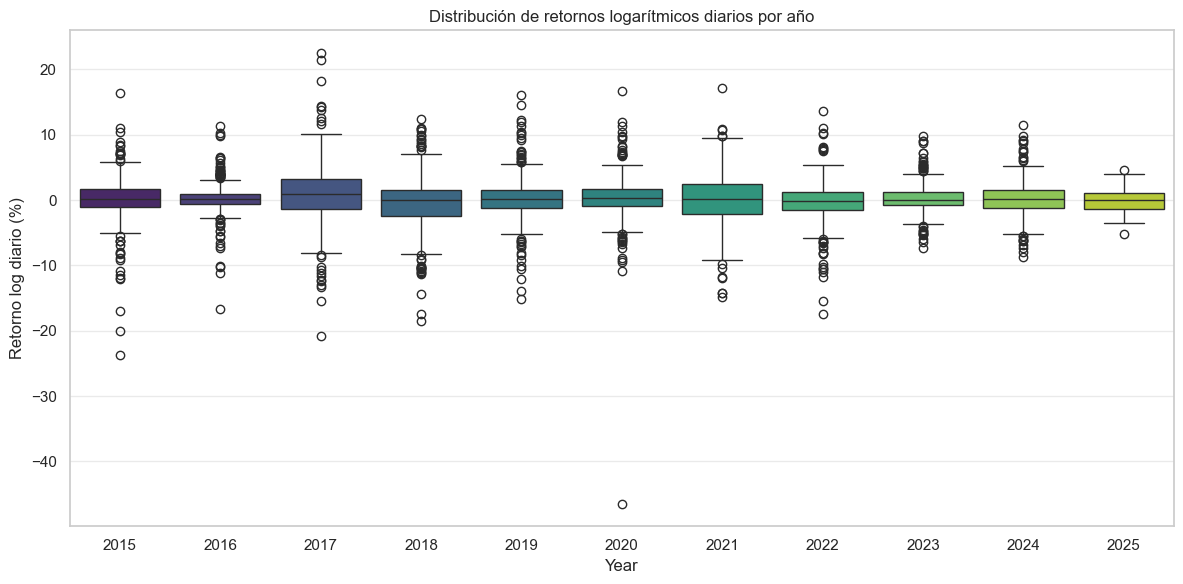

In [51]:
df['Year'] = df.index.year

plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Return_log', data=df, palette='viridis')
plt.title('Distribución de retornos logarítmicos diarios por año')
plt.ylabel('Retorno log diario (%)')
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()

plt.show()

### **Preparación para modelado: Target y features de rezago**

In [ ]:
horizon = 7   # ← CAMBIAR AQUÍ según se elija para el calculo del horizonte esperado

# Target: precio de cierre dentro de 'horizon' días
df['Target'] = df['Close'].shift(-horizon)

# Features de rezago: precios y retornos pasados
lags = [1, 3, 7, 14, 30]

for lag in lags:
    df[f'Close_lag_{lag}']  = df['Close'].shift(lag)
    df[f'Return_log_lag_{lag}'] = df['Return_log'].shift(lag)
    df[f'Vol_30d_lag_{lag}'] = df['Vol_30d'].shift(lag)

# Otras features útiles
df['Day_of_week'] = df.index.dayofweek      # 0 = lunes, 6 = domingo
df['Month']       = df.index.month
df['Quarter']     = df.index.quarter

# Eliminamos filas con NaN (las últimas 'horizon' filas no tienen target, y primeras por lags)
df_model = df.dropna().copy()

print(f"Filas disponibles para modelado: {len(df_model):,}")
print(f"Período modelable: {df_model.index.min().date()} → {df_model.index.max().date()}")
print("\nColumnas disponibles ahora:")
print(df_model.columns.tolist())

# Vista rápida
display(df_model[['Close', 'Target'] + [c for c in df_model.columns if 'lag' in c]].tail(8))

Filas disponibles para modelado: 3,497
Período modelable: 2015-07-19 → 2025-02-12

Columnas disponibles ahora:
['Close', 'High', 'Low', 'Open', 'Volume', 'MA_30', 'MA_200', 'Return_simple', 'Return_log', 'Vol_30d', 'Vol_90d', 'Year', 'Target', 'Close_lag_1', 'Return_log_lag_1', 'Vol_30d_lag_1', 'Close_lag_3', 'Return_log_lag_3', 'Vol_30d_lag_3', 'Close_lag_7', 'Return_log_lag_7', 'Vol_30d_lag_7', 'Close_lag_14', 'Return_log_lag_14', 'Vol_30d_lag_14', 'Close_lag_30', 'Return_log_lag_30', 'Vol_30d_lag_30', 'Day_of_week', 'Month', 'Quarter']


Price,Close,Target,Close_lag_1,Return_log_lag_1,Vol_30d_lag_1,Close_lag_3,Return_log_lag_3,Vol_30d_lag_3,Close_lag_7,Return_log_lag_7,Vol_30d_lag_7,Close_lag_14,Return_log_lag_14,Vol_30d_lag_14,Close_lag_30,Return_log_lag_30,Vol_30d_lag_30
Date,,,,,,,,,,,,,,,,,
2025-02-05,96615.445312,97885.859375,97871.820312,-3.546789,48.694546,97688.976562,-2.991911,45.140539,103703.210938,2.312612,43.413649,103653.070312,-2.376855,47.426341,102078.085938,3.756186,45.037795
2025-02-06,96593.296875,96623.867188,96615.445312,-1.292005,46.925319,101405.421875,3.733784,46.997497,104735.304688,0.990318,43.436387,103960.171875,0.295840,45.374864,96922.703125,-5.182428,48.362742
2025-02-07,96529.085938,97508.968750,96593.296875,-0.022927,43.319736,97871.820312,-3.546789,48.694546,102405.023438,-2.250049,44.311789,104819.484375,0.823181,45.404364,95043.523438,-1.957886,46.989529
2025-02-08,96482.453125,97580.351562,96529.085938,-0.066498,42.748658,96615.445312,-1.292005,46.925319,100655.906250,-1.722794,44.030609,104714.648438,-0.100066,43.339426,92484.039062,-2.729885,47.838193
2025-02-09,96500.093750,96175.031250,96482.453125,-0.048321,41.559292,96593.296875,-0.022927,43.319736,97688.976562,-2.991911,45.140539,102682.500000,-1.959731,43.489458,94701.453125,2.369327,45.703409
2025-02-10,97437.554688,95773.382812,96500.093750,0.018282,40.774431,96529.085938,-0.066498,42.748658,101405.421875,3.733784,46.997497,102087.687500,-0.580958,43.500898,94566.593750,-0.142506,45.587437
2025-02-11,95747.429688,95539.546875,97437.554688,0.966773,40.887588,96482.453125,-0.048321,41.559292,97871.820312,-3.546789,48.694546,101332.476562,-0.742517,43.073051,94488.437500,-0.082681,45.226864
2025-02-12,97885.859375,96635.609375,95747.429688,-1.749792,41.391575,96500.093750,0.018282,40.774431,96615.445312,-1.292005,46.925319,103703.210938,2.312612,43.413649,94516.523438,0.029720,45.233499


### **División cronológica (85% train - 15% test)**

In [53]:
train_pct = 0.85
n_train = int(len(df_model) * train_pct)

df_train = df_model.iloc[:n_train].copy()
df_test  = df_model.iloc[n_train:].copy()

print(f"Train: {len(df_train):,} filas → {df_train.index.min().date()} → {df_train.index.max().date()}")
print(f"Test:  {len(df_test):,} filas  → {df_test.index.min().date()} → {df_test.index.max().date()}")

# Variables predictoras (X) y objetivo (y)
features = [c for c in df_model.columns if 'lag' in c or c in ['Day_of_week', 'Month', 'Quarter', 'Vol_30d', 'Vol_90d']]

X_train = df_train[features]
y_train = df_train['Target']

X_test  = df_test[features]
y_test  = df_test['Target']

print(f"\nNúmero de features: {len(features)}")
print("Ejemplo de features:", features[:8])

Train: 2,972 filas → 2015-07-19 → 2023-09-06
Test:  525 filas  → 2023-09-07 → 2025-02-12

Número de features: 20
Ejemplo de features: ['Vol_30d', 'Vol_90d', 'Close_lag_1', 'Return_log_lag_1', 'Vol_30d_lag_1', 'Close_lag_3', 'Return_log_lag_3', 'Vol_30d_lag_3']


### **Modelo 1: Naive - Predicción = último precio conocido**

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicción naive: el precio de hace 7 días (porque horizonte=7)
# Es decir: para predecir t+7 usamos Close de t
df_test['Naive_Pred'] = df_test['Close_lag_7']   # ya lo tenemos calculado

# Métricas
mae_naive   = mean_absolute_error(df_test['Target'], df_test['Naive_Pred'])
rmse_naive  = np.sqrt(mean_squared_error(df_test['Target'], df_test['Naive_Pred']))
r2_naive    = r2_score(df_test['Target'], df_test['Naive_Pred'])

print("Baseline Naive (último valor conocido - shift 7 días)")
print(f"MAE:   {mae_naive:,.2f} USD")
print(f"RMSE:  {rmse_naive:,.2f} USD")
print(f"R²:    {r2_naive:.4f}")

Baseline Naive (último valor conocido - shift 7 días)
MAE:   4,582.50 USD
RMSE:  6,240.04 USD
R²:    0.9141


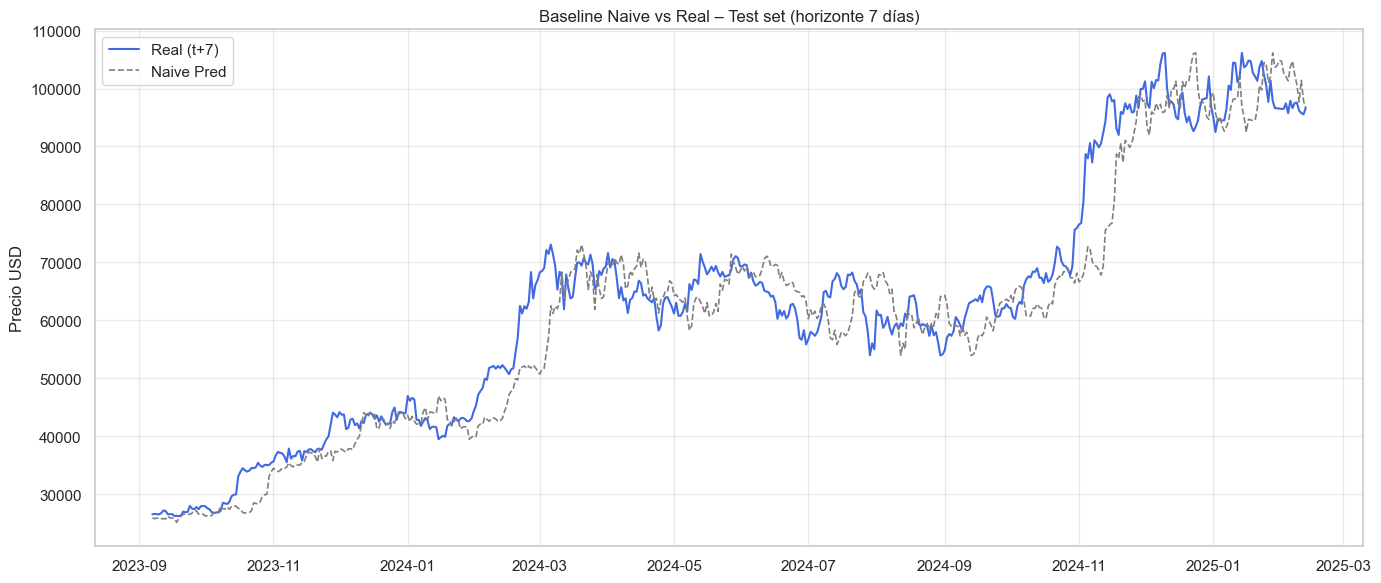

In [55]:
# Gráfico comparativo rápido
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['Target'], label='Real (t+7)', color='royalblue', lw=1.5)
plt.plot(df_test.index, df_test['Naive_Pred'], label='Naive Pred', color='gray', lw=1.2, ls='--')
plt.title('Baseline Naive vs Real – Test set (horizonte 7 días)')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### **Modelo 2: Media Móvil 30 días (usamos la MA_30 como predicción)**

In [56]:
df_test['MA30_Pred'] = df_test['MA_30']

mae_ma30   = mean_absolute_error(df_test['Target'], df_test['MA30_Pred'])
rmse_ma30  = np.sqrt(mean_squared_error(df_test['Target'], df_test['MA30_Pred']))
r2_ma30    = r2_score(df_test['Target'], df_test['MA30_Pred'])

print("Baseline Media Móvil 30 días persistente")
print(f"MAE:   {mae_ma30:,.2f} USD")
print(f"RMSE:  {rmse_ma30:,.2f} USD")
print(f"R²:    {r2_ma30:.4f}")

Baseline Media Móvil 30 días persistente
MAE:   5,215.68 USD
RMSE:  7,076.66 USD
R²:    0.8895


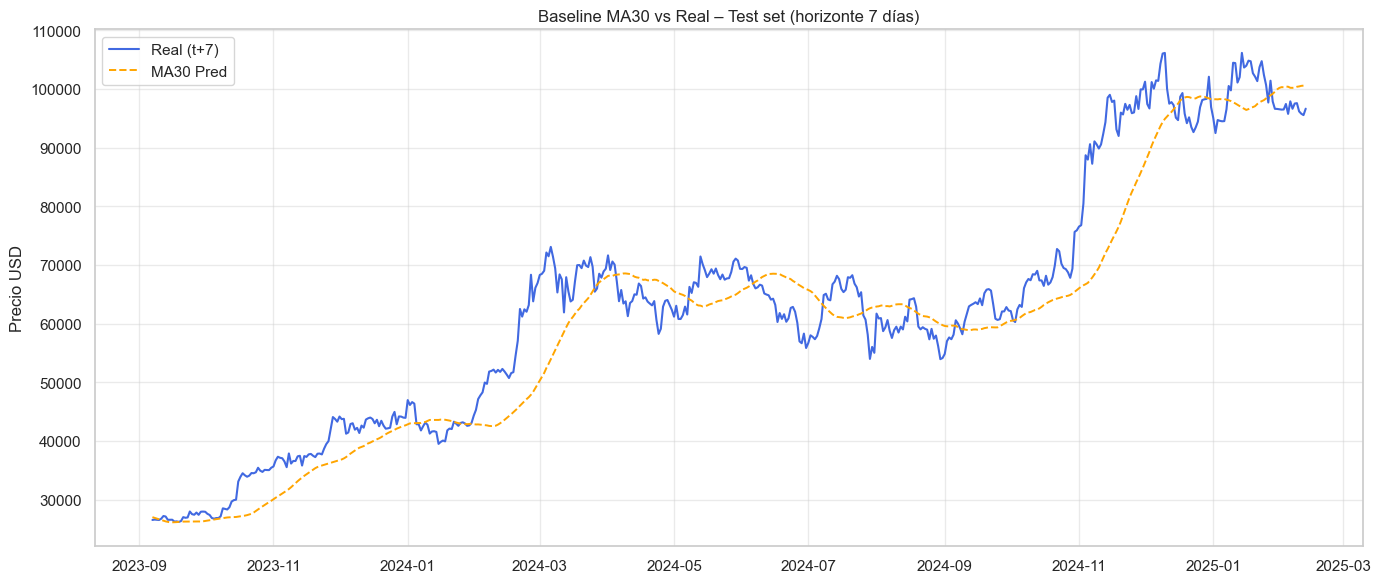

In [57]:
# Gráfico
plt.figure(figsize=(14, 6))
plt.plot(df_test.index, df_test['Target'], label='Real (t+7)', color='royalblue', lw=1.5)
plt.plot(df_test.index, df_test['MA30_Pred'], label='MA30 Pred', color='orange', lw=1.4, ls='--')
plt.title('Baseline MA30 vs Real – Test set (horizonte 7 días)')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### **Mejora del modelo – Exponential Moving Average (EMA)**

In [58]:
# EMA 7 días (más reactiva a cambios recientes)
df_test['EMA_7'] = df_test['Close'].ewm(span=7, adjust=False).mean()

# EMA 14 días (balance entre reactividad y suavizado)
df_test['EMA_14'] = df_test['Close'].ewm(span=14, adjust=False).mean()

# Métricas para EMA 7
mae_ema7  = mean_absolute_error(df_test['Target'], df_test['EMA_7'])
rmse_ema7 = np.sqrt(mean_squared_error(df_test['Target'], df_test['EMA_7']))
r2_ema7   = r2_score(df_test['Target'], df_test['EMA_7'])

# Métricas para EMA 14
mae_ema14  = mean_absolute_error(df_test['Target'], df_test['EMA_14'])
rmse_ema14 = np.sqrt(mean_squared_error(df_test['Target'], df_test['EMA_14']))
r2_ema14   = r2_score(df_test['Target'], df_test['EMA_14'])

print("Baseline EMA 7 días persistente")
print(f"MAE:   {mae_ema7:,.2f} USD")
print(f"RMSE:  {rmse_ema7:,.2f} USD")
print(f"R²:    {r2_ema7:.4f}\n")

print("Baseline EMA 14 días persistente")
print(f"MAE:   {mae_ema14:,.2f} USD")
print(f"RMSE:  {rmse_ema14:,.2f} USD")
print(f"R²:    {r2_ema14:.4f}")

Baseline EMA 7 días persistente
MAE:   3,495.79 USD
RMSE:  4,763.49 USD
R²:    0.9499

Baseline EMA 14 días persistente
MAE:   3,969.04 USD
RMSE:  5,350.24 USD
R²:    0.9369


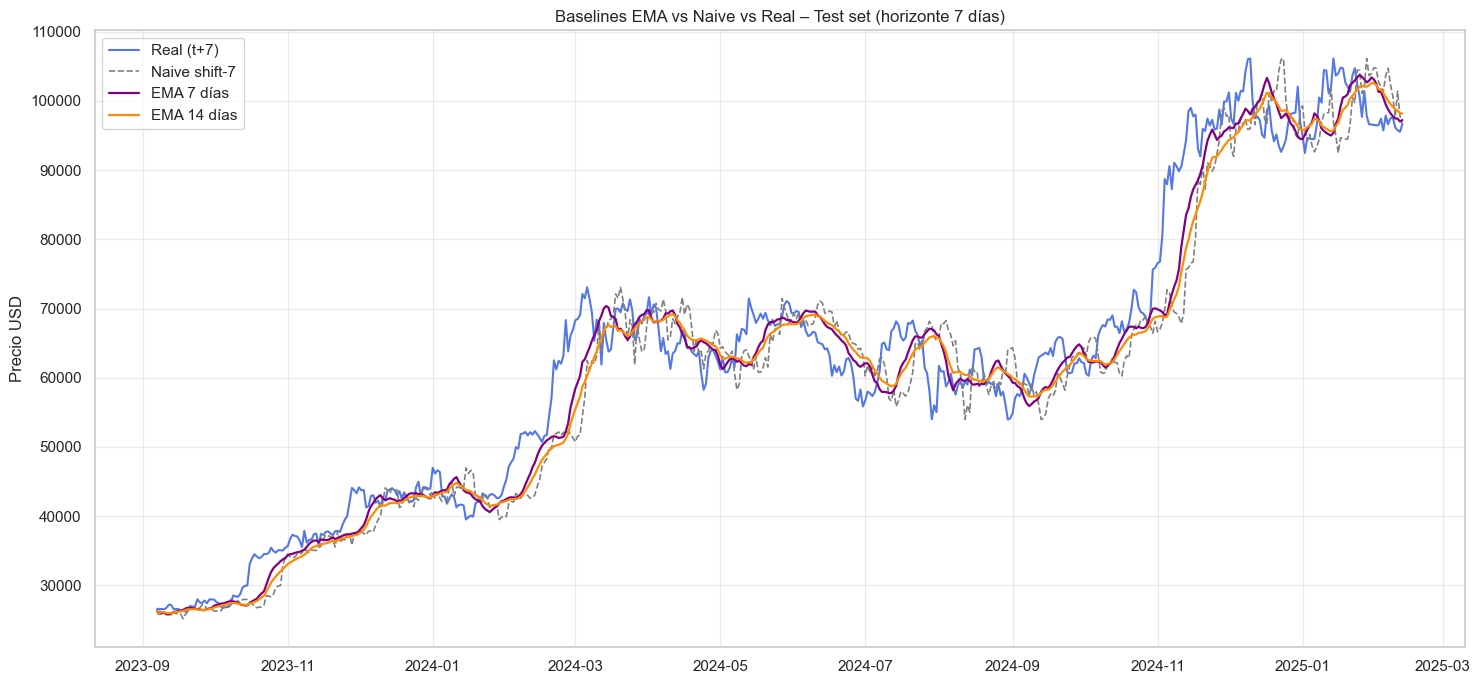

In [59]:
# Gráfico comparativo
plt.figure(figsize=(15, 7))
plt.plot(df_test.index, df_test['Target'], label='Real (t+7)', color='royalblue', lw=1.5, alpha=0.9)
plt.plot(df_test.index, df_test['Naive_Pred'], label='Naive shift-7', color='gray', lw=1.2, ls='--')
plt.plot(df_test.index, df_test['EMA_7'], label='EMA 7 días', color='purple', lw=1.6)
plt.plot(df_test.index, df_test['EMA_14'], label='EMA 14 días', color='darkorange', lw=1.6)
plt.title('Baselines EMA vs Naive vs Real – Test set (horizonte 7 días)')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### **Modelo ML: XGBoost Regressor con features de rezago**

In [ ]:
import xgboost as xgb

# Parámetros básicos
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

# Entrenamos
print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# Métricas
mae_xgb   = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb  = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb    = r2_score(y_test, y_pred_xgb)

print("\nResultados XGBoost en Test set")
print(f"MAE:   {mae_xgb:,.2f} USD")
print(f"RMSE:  {rmse_xgb:,.2f} USD")
print(f"R²:    {r2_xgb:.4f}")

Entrenando XGBoost...

Resultados XGBoost en Test set
MAE:   19,586.32 USD
RMSE:  25,856.31 USD
R²:    -0.4748


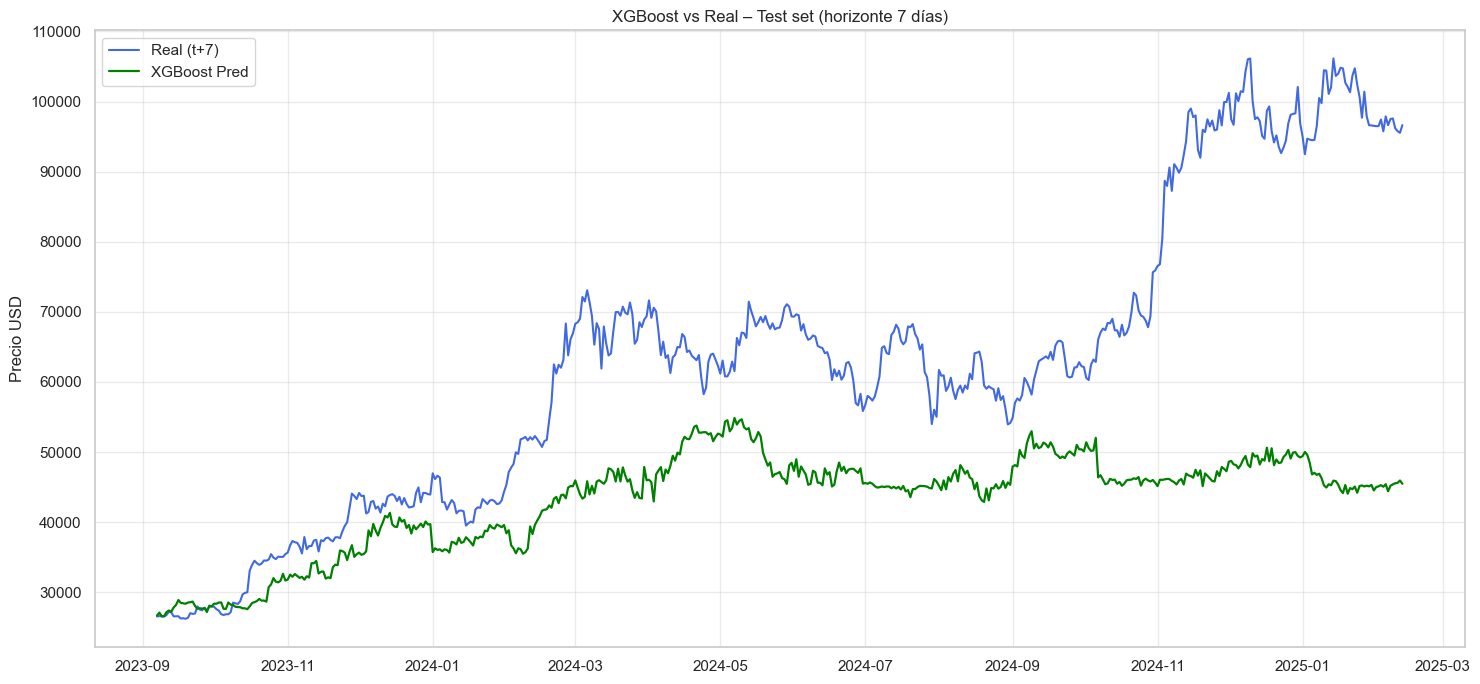

In [61]:
# Gráfico de predicciones vs real
plt.figure(figsize=(15, 7))
plt.plot(df_test.index, y_test, label='Real (t+7)', color='royalblue', lw=1.5)
plt.plot(df_test.index, y_pred_xgb, label='XGBoost Pred', color='green', lw=1.6)
plt.title('XGBoost vs Real – Test set (horizonte 7 días)')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

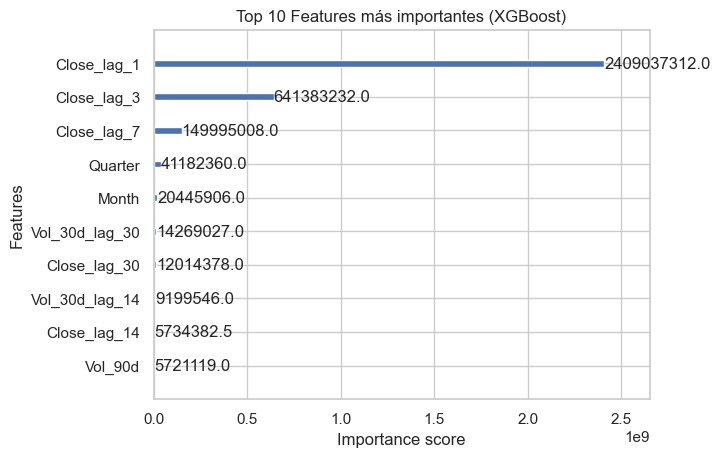

In [62]:
# Importancia de features (top 10)
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain')
plt.title('Top 10 Features más importantes (XGBoost)')
plt.show()